In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r'D:\Data Analytics\sales_analysis\dataset\sales_clean_data.xlsx' , sheet_name='Sales Data')
df.head(5)

,order_id,year,month,order_date,ship_date,ship_mode,customer_id,customer_name,client_segment,country,...,product_name,sales_price,quantity,discount,total_sales_amount,purchasing_price,total_purchasing_amounts,net_profit,shipping_days,profit_margin_%
0,CA-2016-152156,2016,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Bush Somerset Collection Bookcase,261.9600,2,0.0,523.9200,157.17600,314.35200,209.56800,3,40.0
1,CA-2016-152156,2016,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.0,2195.8200,402.56700,1207.70100,988.11900,3,45.0
2,CA-2016-138688,2016,Jun,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.0,29.2400,8.77200,17.54400,11.69600,4,40.0
3,US-2015-108966,2015,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.0,4787.8875,478.78875,2393.94375,2393.94375,7,50.0
4,US-2015-108966,2015,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.2,35.7888,11.18400,22.36800,13.42080,7,37.5


In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
year,1006.0,2015.656064,2014.0,2015.0,2016.0,2017.0,2017.0,1.109434
order_date,1006,2016-04-04 22:35:32.803180800,2014-01-04 00:00:00,2015-04-26 00:00:00,2016-05-30 00:00:00,2017-04-07 00:00:00,2017-12-30 00:00:00,NaN
ship_date,1006,2016-04-08 22:49:51.650099456,2014-01-08 00:00:00,2015-05-02 00:00:00,2016-06-04 00:00:00,2017-04-11 00:00:00,2018-01-05 00:00:00,NaN
postal_code,1006.0,53709.311133,1841.0,19308.5,51461.5,85254.0,98661.0,31699.374286
sales_price,1006.0,238.360934,1.08,18.498,55.49,209.9175,8159.952,595.524062
quantity,1006.0,3.808151,1.0,2.0,3.0,5.0,14.0,2.272477
discount,1006.0,0.079016,0.0,0.0,0.0,0.2,0.32,0.099007
total_sales_amount,1006.0,1109.855877,1.68,44.9052,162.72,731.2866,65279.616,3658.377546
purchasing_price,1006.0,143.664889,0.648,11.1022,33.215,121.8003,5303.9688,360.031046
total_purchasing_amounts,1006.0,719.546625,0.924,29.504,113.476,485.603125,42431.7504,2280.609856


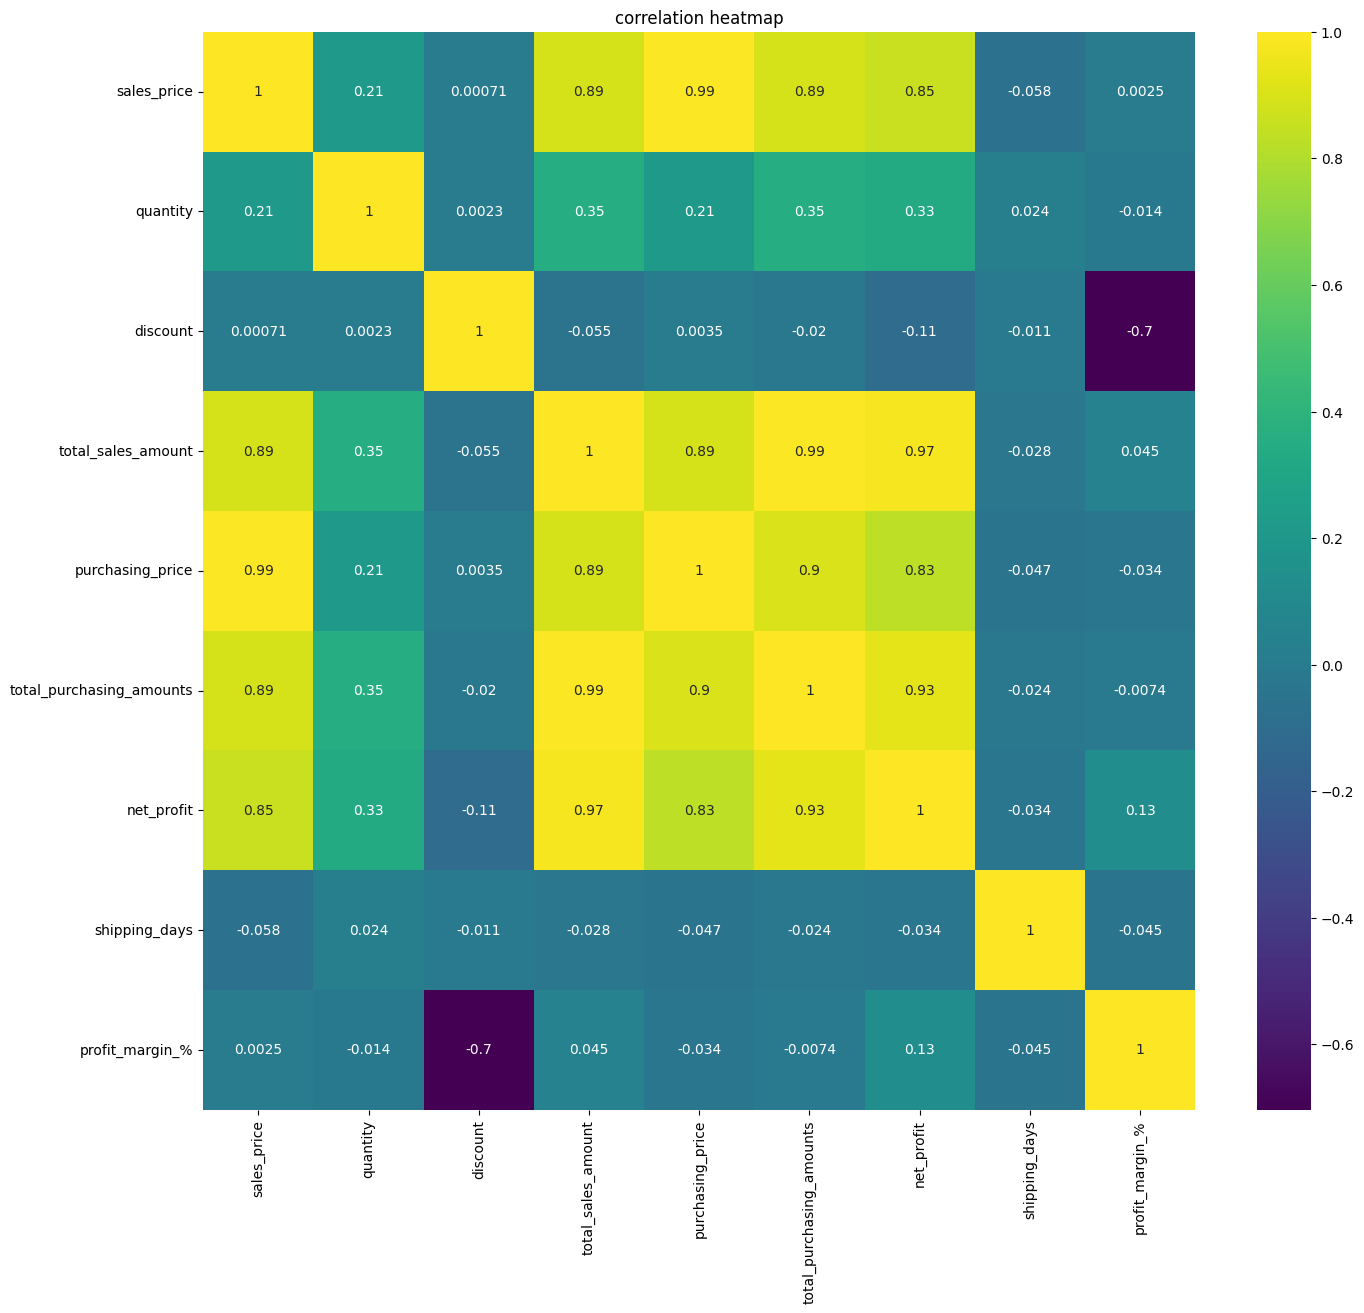

In [5]:
drop_col = df.drop(columns=['year' , 'postal_code'])
numeric_cols = drop_col.select_dtypes(include=['int64','float32','int32','float64'])
plt.figure(figsize=(16,14))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlation heatmap")
plt.show()

**1. Strong positive relationships among price, cost, sales, and profit**

Sales Price, Purchasing Price, Total Sales Amount, Total Purchasing Amounts, and Net Profit are highly correlated (0.83 to 0.99).

**2. Discount strongly reduces profit margin**

Discount has a clear negative correlation of –0.7 with Profit Margin %.

**3. Shipping days and most other factors have almost no relationship**

Shipping Days shows near-zero correlation with every sales and profit metric. Profit Margin % itself is largely independent of Sales Price, Quantity, and costs (near zero), except for the strong negative link with Discount.

* show outliers 

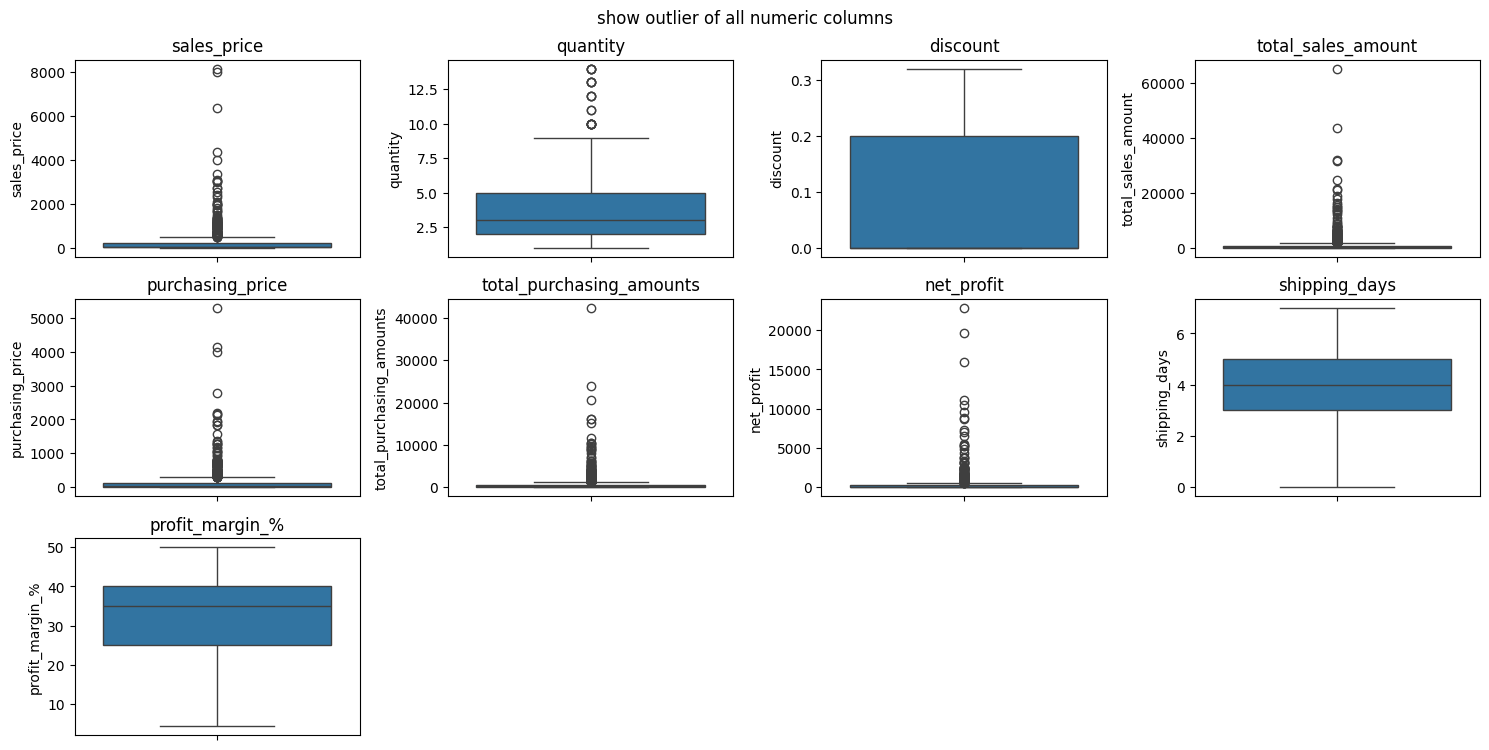

In [12]:
# numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.boxplot(df[col])
    plt.title(col)
plt.suptitle('show outlier of all numeric columns')
plt.tight_layout()
plt.show()

In [17]:
# how many outlier in column??
def detect_outliers(df , col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = ((df[col] < lower_bound) | (df[col] > upper_bound))
    print(f"IQR method identified {outliers_iqr.sum()} outliers in {col}")
    return outliers_iqr

outlier_col = ['sales_price' , 'total_sales_amount' , 'purchasing_price' , 'total_purchasing_amounts']

for col in outlier_col:
    detect_outliers(df ,col)

IQR method identified 117 outliers in sales_price
IQR method identified 129 outliers in total_sales_amount
IQR method identified 122 outliers in purchasing_price
IQR method identified 128 outliers in total_purchasing_amounts


# analysis 📊

In [29]:
# 1 . KPI
overall_profit_margin = df['net_profit'].sum() / df['total_sales_amount'].sum() * 100
print(f'overall profit margin {overall_profit_margin.round(2)}%')

tota_sales = df['total_sales_amount'].sum()
print(f'overall sales {tota_sales.round(2)}')

overall_purchase_amount = df['total_purchasing_amounts'].sum()
print(f'overall purchase amount {overall_purchase_amount.round(2)}')

total_orders = df['order_id'].nunique()
print(f'total orders {total_orders}')

total_customers = df['customer_id'].nunique()
print(f'total customers {total_customers}')



overall profit margin 35.17%
overall sales 1116515.01
overall purchase amount 723863.9
total orders 488
total customers 366


**yearly net profit and total sale**

,total_net_profit
year,
2014,108999.60
2015,90329.20
2016,102445.66
2017,90876.64


,total_sale
year,
2014,323177.92
2015,255589.37
2016,286503.79
2017,251243.93


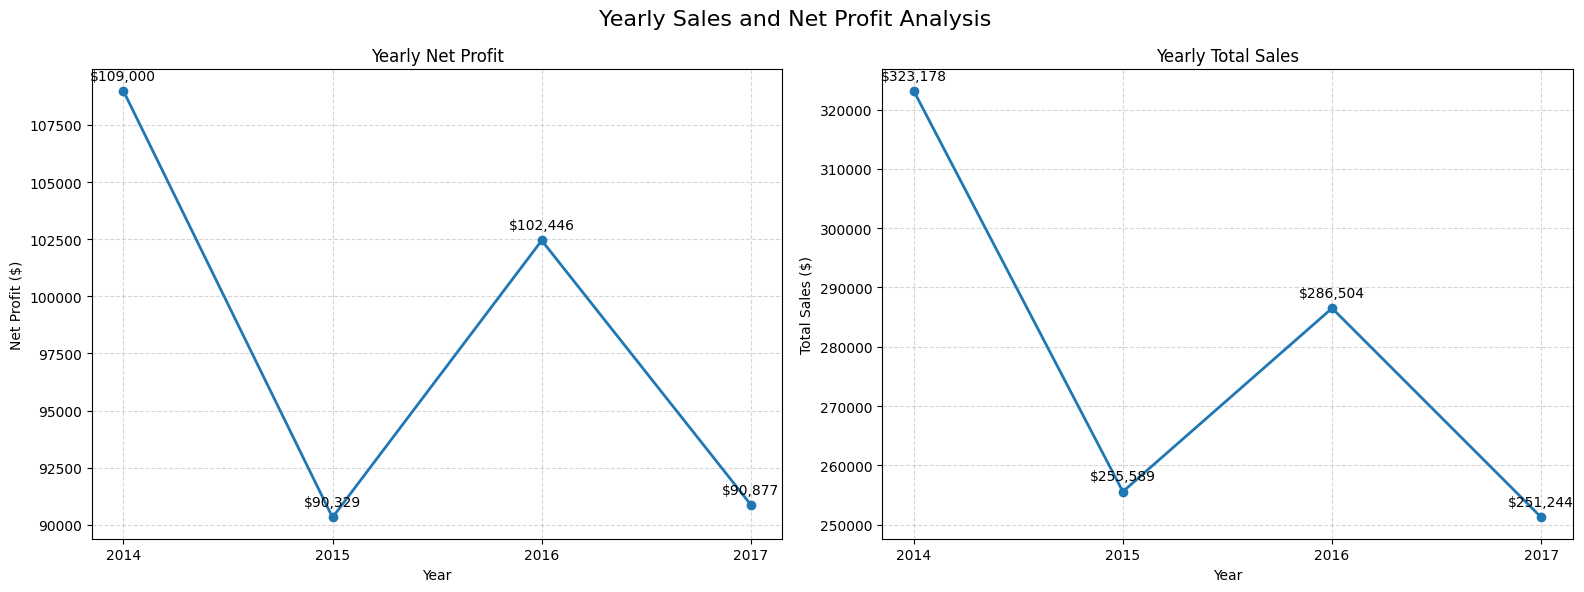

In [47]:
yearly_net_profit = df.groupby('year').agg(
    total_net_profit = ('net_profit' , 'sum')
)
yearly_net_profit = yearly_net_profit.sort_values(by='year')
display(yearly_net_profit.round(2))

yearly_total_sale = df.groupby('year').agg(
    total_sale = ('total_sales_amount' , 'sum')
)
yearly_total_sale = yearly_total_sale.sort_values(by='year')
display(yearly_total_sale.round(2))
# -------------------------------
# Create subplots
# -------------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)


# =================================
# 1. Yearly Net Profit
# =================================
axes[0].plot(
    yearly_net_profit.index,
    yearly_net_profit['total_net_profit'],
    marker='o',
    linewidth=2
)

for year, profit in yearly_net_profit['total_net_profit'].items():
    axes[0].annotate(
        f'${profit:,.0f}',
        (year, profit),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

axes[0].set_title('Yearly Net Profit')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Net Profit ($)')
axes[0].set_xticks(yearly_net_profit.index)
axes[0].grid(
    True,
    linestyle='--',
    alpha=0.5
)


# =================================
# 2. Yearly Total Sales
# =================================
axes[1].plot(
    yearly_total_sale.index,
    yearly_total_sale['total_sale'],
    marker='o',
    linewidth=2
)

for year, sale in yearly_total_sale['total_sale'].items():
    axes[1].annotate(
        f'${sale:,.0f}',
        (year, sale),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

axes[1].set_title('Yearly Total Sales')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Sales ($)')
axes[1].set_xticks(yearly_total_sale.index)
axes[1].grid(
    True,
    linestyle='--',
    alpha=0.5
)


# Overall title
fig.suptitle(
    'Yearly Sales and Net Profit Analysis',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [54]:
region_order = df.groupby('region').agg(
    total_orders = ('order_id' , 'nunique') , 
    total_orders_line = ('order_id' , 'count')
).sort_values(by='total_orders' , ascending=False)
display(region_order.round(2))

,total_orders,total_orders_line
region,,
West,152,311
East,137,313
Central,121,241
South,78,141


**region wise total sale**

,total_sale,total_orders
region,,
West,341156.92,152
Central,308258.67,121
East,286321.21,137
South,180778.22,78


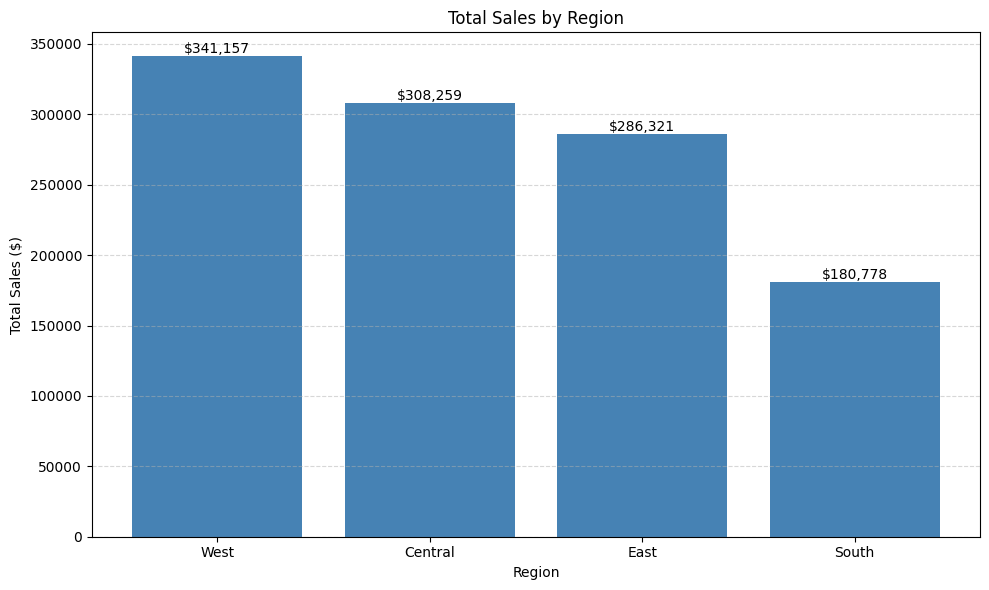

In [57]:
region_sale = df.groupby('region').agg(
    total_sale = ('total_sales_amount' , 'sum') , 
    total_orders = ('order_id' , 'nunique')
).sort_values(by='total_sale' , ascending=False)
display(region_sale.round(2))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    region_sale.index,
    region_sale['total_sale'],
    color='steelblue'
)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**top 10 higest sale state**

,total_sale,total_order
state,,
California,200615.23,96
Texas,141770.46,42
New York,133024.81,60
Pennsylvania,96333.63,30
Washington,59642.98,22
Michigan,55658.63,19
North Carolina,45533.80,15
Illinois,42035.39,30
Georgia,38382.84,4


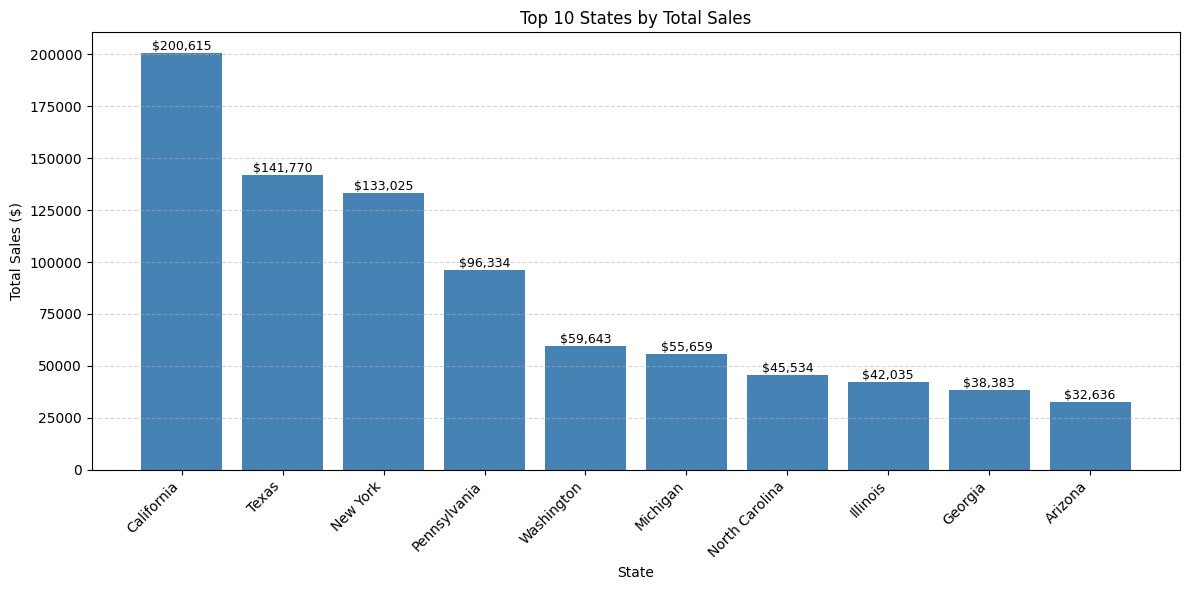

In [60]:
state_sale = df.groupby('state').agg(
    total_sale = ('total_sales_amount' , 'sum'),
    total_order = ('order_id' , 'nunique')
).sort_values(by='total_sale' , ascending=False).head(10)
display(state_sale.round(2))

plt.figure(figsize=(12, 6))

bars = plt.bar(
    state_sale.index,
    state_sale['total_sale'],
    color='steelblue'
)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 10 States by Total Sales')
plt.xlabel('State')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**product category wise total sale**

In [64]:
product_cat_sale = df.groupby('product_category').agg(
    total_sale = ('total_sales_amount' , 'sum') , 
    total_order = ('order_id' , 'nunique')
).sort_values(by='total_sale' , ascending=False)
display(product_cat_sale)

,total_sale,total_order
product_category,,
Technology,462915.90370,161
Furniture,350229.84414,170
Office Supplies,303369.26420,369
